# FPC1500 Network Analyzer - S21 (Transmission)

Kurz zur Theorie (Zweitor, Streuparameter):

Ein lineares Zweitor wird mit einlaufenden Wellen $a_1, a_2$ und auslaufenden Wellen $b_1, b_2$ beschrieben:

$$\begin{bmatrix} b_1 \\ b_2 \end{bmatrix} =
\begin{bmatrix} S_{11} & S_{12} \\ S_{21} & S_{22} \end{bmatrix}
\begin{bmatrix} a_1 \\ a_2 \end{bmatrix}$$

Mit Anregung an Port 1 und Abschluss an Port 2 ($a_2=0$) gilt:

$$S_{21} = \frac{b_2}{a_1}$$

Damit ist $S_{21}$ der Vorwärts-Transmissionsfaktor (Durchlass vom Eingang Port 1 zum Ausgang Port 2).

In diesem Notebook wird **einmal** `TRACE1` als Transmission gelesen und als
**Return/Transmission-Darstellung in dB** geplottet: $20\log_{10}(|S_{21}|)$.

Am Ende wird ein Screenshot vom Gerät eingelesen.

## Geräte-Kalibration
Wähle einen Frequenzbereich, z.B. **2MHz - 30MHz**. (das Gerät als Network-Analyzer arbeitet erst ab 2 MHz).  

- Verbinde den Generator-Output $50\Omega$ mit einem BNC-Koaxialkabel RG58 (0.5m) mit dem RF Input $50\Omega$  
- Im Menü wähle:  Meas --> Transmission (S21) --> Calibrate --> Normalize S21  
- Nach dem Drücken des **Normalize S21** Buttons erscheint die **Calibrate Through** Einstellung, hier drücke den **Continue**-Button.  

Führe das Notebook zu Ende, und analysiere die MEssung des S21-Parameters, idealerweise sollte er **exakt 0dB** (d.h. keine Dämpfung) über den gesamten gemessenen Frequenzbereich sein.

Mit dieser Through-Kalibration soll der Einfluss des Koaxialkabels eliminiert werden (dieses hat natürlich eine reale Dämpfung).

Danach folgt eine S21-Messung eines Zweitors (Schaltung mit 2 Anschlüssen) in Notebook 2-fpc1500-NA-S21.ipynb.





![S21 Normalization ](media\S21-calibration.jpg)

## Imports und Globale Parameter

In [16]:
import json
import socket
from datetime import datetime
from pathlib import Path

# Interaktive Matplotlib-Widgets (Slider) in Jupyter: ipympl installieren, dann:
#   pip install ipympl
# Ohne ipympl nutzt oft das statische "inline"-Backend — der Slider erscheint, ist aber nicht ziehbar.
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np
from IPython.display import Image, display

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 15.0   # HCOP und Auslesen können deutlich länger als 5 s dauern
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024

# Offline-Workflow: bei REPLAY=True werden Messdaten aus JSON geladen
REPLAY = True
REPLAY_FILE = Path("recordings") / "1-fpc1500_na_s21_replay.json"

SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

print(f"Konfiguration: {FPC_IP}:{FPC_PORT}")
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")

Konfiguration: 192.168.1.10:5555
REPLAY=True, Datei=recordings\1-fpc1500_na_s21_replay.json


In [13]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def parse_float_list(raw: str) -> np.ndarray:
    vals = []
    for part in raw.replace(",", " ").split():
        try:
            vals.append(float(part))
        except ValueError:
            continue
    return np.asarray(vals, dtype=np.float64)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    try:
        f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
        f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    except Exception:
        cent = float(scpi_query(host, port, "FREQ:CENT?", max_bytes=256))
        span = float(scpi_query(host, port, "FREQ:SPAN?", max_bytes=256))
        f_start = cent - span / 2.0
        f_stop = cent + span / 2.0
    return np.linspace(f_start, f_stop, n)

def to_s21_db(vals: np.ndarray) -> tuple[np.ndarray, str]:
    if vals.size == 0:
        return vals, "empty"
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    looks_like_db = vmax <= 40.0 and vmin < 20.0
    if looks_like_db:
        return vals, "already_dB"
    s21_db = 20.0 * np.log10(np.maximum(np.abs(vals), 1e-12))
    return s21_db, "linear_to_dB"


def save_replay_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    """Hardcopy auf dem Gerät auslösen und in MMEM speichern. Returns None bei Erfolg, sonst Fehlermeldung."""
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < 4096:
            try:
                chunk = s.recv(1024)
                if not chunk:
                    break
                buf += chunk
                if b"\n" in buf:
                    break
            except socket.timeout:
                break
        reply = buf.decode("utf-8", errors="replace").strip()
        if reply and "error" in reply.lower():
            return reply
        return None
    except Exception as e:
        return str(e)
    finally:
        s.close()


def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    """Datei vom Gerät (MMEM) lesen. MMEM:DATA? Antwort im IEEE 488.2-Blockformat. Returns PNG-Bytes oder None."""
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        if len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        if n_digits < 1 or n_digits > 9:
            return None
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2 : 2 + n_digits].decode())
        buf = buf[2 + n_digits :]
        while len(buf) < data_len:
            chunk = s.recv(min(65536, data_len - len(buf)))
            if not chunk:
                break
            buf += chunk
        return buf[:data_len] if len(buf) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

## Messung S21 aus TRACE1

Bitte am Gerät die Transmission (S21) aktiv darstellen und dann diese Zelle ausführen.
Die Zelle liest `TRACE1` einmal ein und plottet $20\log_{10}(|S_{21}|)$ über der Frequenz.

Gerät: Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90
Replay gespeichert: recordings\1-fpc1500_na_s21_replay.json


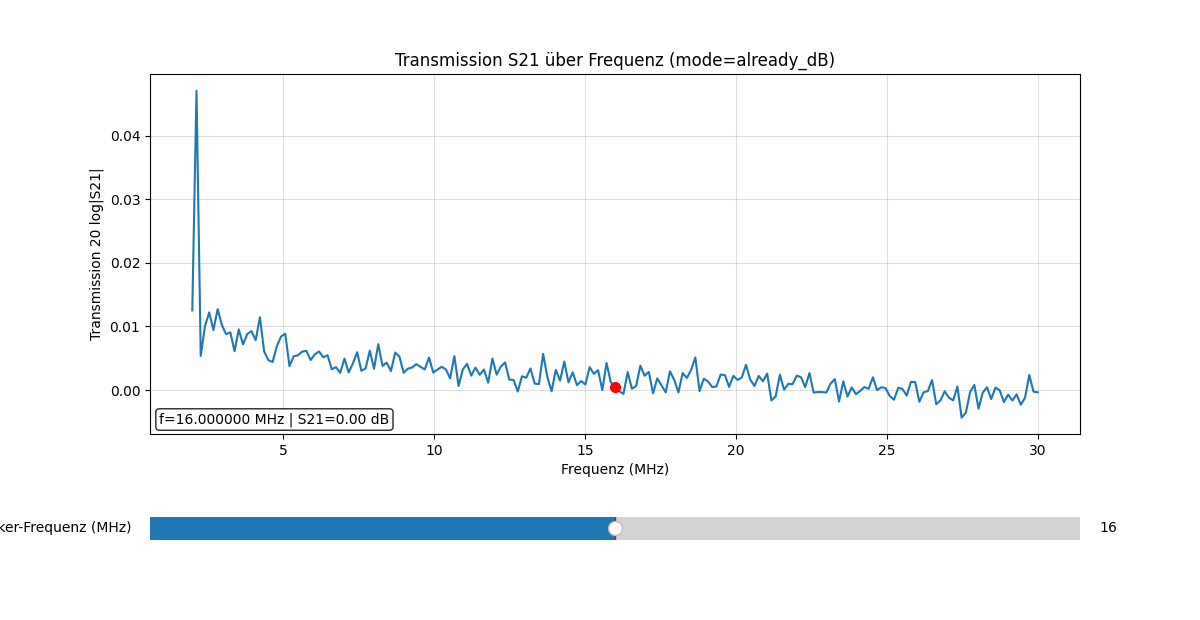

In [14]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    freq_hz = np.asarray(replay["freq_hz"], dtype=float)
    trace_vals = np.asarray(replay["trace_vals"], dtype=float)
    s21_db = np.asarray(replay["s21_db"], dtype=float)
    s21_mode = replay.get("s21_mode", "replay")
    idn = replay.get("idn", "REPLAY")
    print("Replay geladen:", REPLAY_FILE)
    print("Gerät:", idn)
else:
    idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
    print("Gerät:", idn if idn else "Keine Antwort")

    trace_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    trace_vals = parse_float_list(trace_raw)
    if trace_vals.size < 2:
        raise RuntimeError("TRACE1 leer. Bitte S21-Transmission am Gerät einstellen.")

    freq_hz = get_freq_axis(FPC_IP, FPC_PORT, trace_vals.size)
    s21_db, s21_mode = to_s21_db(trace_vals)

    save_replay_json(
        REPLAY_FILE,
        {
            "meta": {"type": "fpc1500_na_s21", "version": 1},
            "idn": idn,
            "s21_mode": s21_mode,
            "freq_hz": freq_hz.tolist(),
            "trace_vals": trace_vals.tolist(),
            "s21_db": s21_db.tolist(),
        },
    )
    print("Replay gespeichert:", REPLAY_FILE)

f_mhz = freq_hz / 1e6

fig = plt.figure(figsize=(12, 6.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.13], hspace=0.35)
ax = fig.add_subplot(gs[0, 0])
ax_slider = fig.add_subplot(gs[1, 0])

ax.plot(f_mhz, s21_db, color="C0", lw=1.5)
ax.set_title(f"Transmission S21 über Frequenz (mode={s21_mode})")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Transmission 20 log|S21|")
ax.grid(True, alpha=0.4)

idx0 = int(np.argmin(np.abs(f_mhz - np.mean(f_mhz))))
m_s21, = ax.plot([f_mhz[idx0]], [s21_db[idx0]], "o", color="red", ms=7)
# Text im Haupt-Plot (transAxes), nicht fig.text am unteren Figurenrand — sonst überlappt
# der unsichtbare Kasten die Slider-Achse und blockiert Maus-Events.
info_text = ax.text(
    0.01,
    0.02,
    "",
    transform=ax.transAxes,
    fontsize=10,
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85),
)

slider = Slider(
    ax=ax_slider,
    label="Marker-Frequenz (MHz)",
    valmin=float(f_mhz.min()),
    valmax=float(f_mhz.max()),
    valinit=float(f_mhz[idx0]),
)

def update_marker(f_sel_mhz):
    idx = int(np.argmin(np.abs(f_mhz - f_sel_mhz)))
    m_s21.set_data([f_mhz[idx]], [s21_db[idx]])
    info_text.set_text(f"f={f_mhz[idx]:.6f} MHz | S21={s21_db[idx]:.2f} dB")
    fig.canvas.draw_idle()

slider.on_changed(update_marker)
update_marker(f_mhz[idx0])
plt.show()

Gespeichert: C:\_Git\KT-workspace\lab_suite\labs\06_01_LABOR-7-solution\screenshots\1-fpc1500_na_s21_screenshot.png


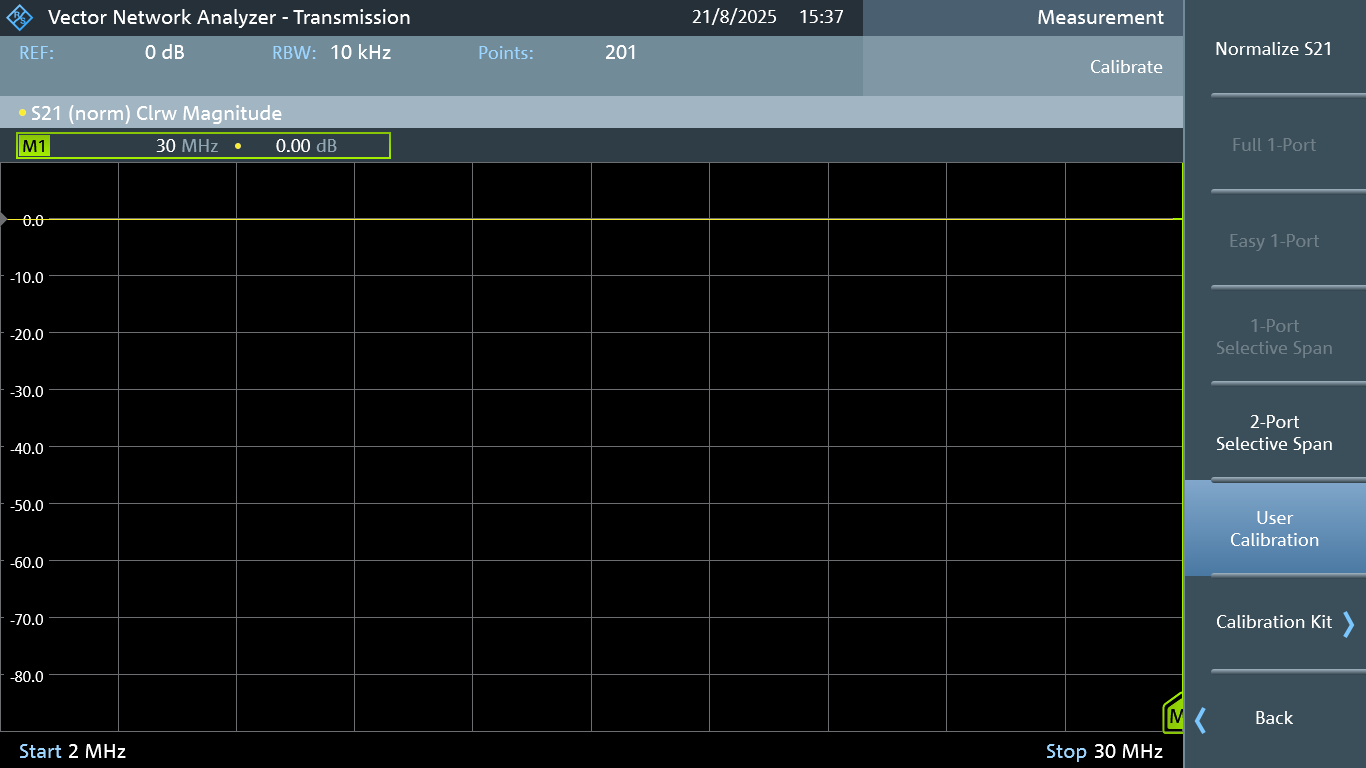

Replay aktualisiert mit screenshot_path: recordings\1-fpc1500_na_s21_replay.json


In [15]:
# Screenshot-Handling:
# - REPLAY=False: Screenshot am Gerät auslösen, lokal speichern und Replay-Datei damit verknüpfen
# - REPLAY=True : bereits aufgezeichneten Screenshot aus Replay-Datei anzeigen (kein neuer Trigger)
# (Am Gerät sollte bei Live-Messung die S21-Transmission sichtbar sein.)

SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    shot_path_str = replay.get('screenshot_path', '')
    shot_path = Path(shot_path_str) if shot_path_str else None

    if shot_path and shot_path.exists():
        print('Replay-Screenshot geladen:', shot_path)
        display(Image(filename=str(shot_path)))
    else:
        print('REPLAY=True: Kein gültiger screenshot_path in Replay-Datei vorhanden.')
        if shot_path_str:
            print('Gespeicherter Pfad (nicht gefunden):', shot_path_str)
else:
    err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if err:
        print('Screenshot speichern auf dem Gerät fehlgeschlagen:', err)
    else:
        png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
        if png_bytes:
            out_path = SCREENSHOT_DIR / f"{REPLAY_FILE.stem.replace('_replay', '')}_screenshot.png"
            out_path.write_bytes(png_bytes)
            print('Gespeichert:', out_path.resolve())
            display(Image(data=png_bytes))

            try:
                replay = load_replay_json(REPLAY_FILE) if REPLAY_FILE.exists() else {}
                replay['screenshot_path'] = str(out_path)
                save_replay_json(REPLAY_FILE, replay)
                print('Replay aktualisiert mit screenshot_path:', REPLAY_FILE)
            except Exception as ex:
                print('Hinweis: screenshot_path konnte nicht im Replay gespeichert werden:', ex)
        else:
            print('Screenshot konnte nicht gelesen werden.')